# PTT Tech_Job 版 AI 討論主題分析與情緒探勘

## 組員資訊
- 姓名：
N134020002 陳昱璇
N134020007 林妤綺
N134320018 許季盈
N134320023 黃可欣

- 課程：社群媒體分析

## 研究目的
隨著 AI 技術快速發展，台灣科技業職場對 AI 相關議題的討論日益熱烈。
本專案透過爬取 PTT Tech_Job 版含「AI」關鍵字的貼文，運用文字探勘技術分析：

1. 台灣職場社群最關注 AI 的哪些面向？（LDA 主題模型）
2. 不同主題下引導式主題為何？（Guided LDA）
3. 各主題的情緒傾向為何？（情緒分析）
4. 哪些關鍵字最常出現？（文字雲）

## 資料來源
PTT Tech_Job 版，爬取含「AI」關鍵字之貼文，共 245 篇。

In [8]:
!pip install requests beautifulsoup4 jieba gensim pyLDAvis snownlp wordcloud matplotlib pandas -q
print('套件安裝完成！')

套件安裝完成！


In [9]:
import warnings
# Suppress DeprecationWarning specifically from jupyter_client
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ptt專案/ptt_AI.csv')
print(f'總共 {len(df)} 篇文章')
print(f'欄位：{df.columns.tolist()}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
總共 7457 篇文章
欄位：['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate', 'dataSource']


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/job/M.1704162712.A.780....,[台北/新莊]文化部-公關助理駐點人員,2024-01-02 10:31:50,yangtze,job,job版禁止張貼違反「\n就業服務法\n」、\n「\n性別平等工作法\n」、\n「\n勞基法...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""cin"", ""cmtCo...",211.75.80.216,2024-01-03 02:00:15,ptt
1,2,https://www.ptt.cc/bbs/job/M.1704163913.A.F2D....,[北部/大園]正工程師_飛航服務總臺_大園,2024-01-02 10:51:51,doaskmewhy,job,聘用人員 正工程師\n一、網路及資安設備規劃、建置、管理與維護監控等業務。\n二、飛航服務技...,[],203.74.133.54,2024-01-03 02:00:15,ptt
2,3,https://www.ptt.cc/bbs/job/M.1704186702.A.38B....,[新北]中和承新國際徵網站/平面美編設計師,2024-01-02 17:11:40,chiefEO,job,job版禁止張貼違反「\n就業服務法\n」、\n「\n性別平等工作法\n」、\n「\n勞基法...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""chinaeatshit...",114.34.124.216,2024-01-03 02:00:15,ptt
3,4,https://www.ptt.cc/bbs/job/M.1704187456.A.25F....,[台北/派遣]公家機關_行政人員(職務代理),2024-01-02 17:24:14,klblue84,job,job版禁止張貼違反「\n就業服務法\n」、\n「\n性別平等工作法\n」、\n「\n勞基法...,[],122.116.23.45,2024-01-03 02:00:15,ptt
4,5,https://www.ptt.cc/bbs/job/M.1704191300.A.D03....,[台北]台北醫學大學醫科所誠徵專任助理1名,2024-01-02 18:28:18,sumtrue,job,job版禁止張貼違反「\n就業服務法\n」、「\n性別平等工作法\n」、「\n勞基法\n」與...,[],223.137.221.90,2024-01-03 02:00:15,ptt


## 資料前處理
進行以下步驟：
1. 合併標題與內文
2. 清除網址、標點、換行等雜訊
3. jieba 中文斷詞
4. 停用字清除

### 自定義 Jieba 字典

您可以透過兩種方式自定義 Jieba 的字典：

1.  **`jieba.add_word('您的詞彙')`**：動態地添加單個詞彙到 Jieba 的詞典中。這適用於需要快速添加少量詞彙的場景。
2.  **`jieba.load_userdict('字典檔案路徑')`**：載入一個自定義字典檔案。這個檔案通常是一個純文字檔案，每行一個詞彙，可以選擇性地加上詞頻和詞性標註，例如：`新詞 10 n`。這適用於需要添加大量詞彙或維護一個專用詞庫的場景。

添加自定義詞彙可以幫助 Jieba 更準確地識別特定的專有名詞、技術術語或您希望被視為單個單位的詞組，而不是將它們斷成更小的詞彙。

In [11]:
import re
import jieba
import warnings
warnings.filterwarnings('ignore')

# --- 開始自定義 Jieba 字典 --- #

# 1. 使用 jieba.add_word() 添加單個詞彙
jieba.add_word('台積電', freq=200, tag='n') # 提高'台積電'的詞頻，確保被視為單詞
jieba.add_word('半導體產業', freq=200, tag='n')
jieba.add_word('人工智慧', freq=200, tag='n')
jieba.add_word('機器學習', freq=180, tag='n')
jieba.add_word('深度學習', freq=180, tag='n')
jieba.add_word('神經網路', freq=150, tag='n')
jieba.add_word('演算法', freq=150, tag='n')
jieba.add_word('資料科學', freq=150, tag='n')
jieba.add_word('數據分析', freq=150, tag='n')
jieba.add_word('雲端運算', freq=150, tag='n')
jieba.add_word('大數據', freq=150, tag='n')
jieba.add_word('自然語言處理', freq=150, tag='n')
jieba.add_word('電腦視覺', freq=150, tag='n')
jieba.add_word('生成式AI', freq=200, tag='n') # 再次強調，確保優先度
jieba.add_word('輝達', freq=200, tag='n') # 確保NVIDIA的中文譯名被正確識別
jieba.add_word('英特爾', freq=180, tag='n') # 考慮'英特'可能是'英特爾'的簡稱
jieba.add_word('黃仁勳', freq=180, tag='n')

# 2. 使用 jieba.load_userdict() 載入自定義字典檔案
# 通常你會將自定義詞彙儲存在一個檔案中，這裡為示範創建一個臨時檔案
import os
import tempfile

custom_dict_content = [
    "生成式AI 100 n",
    "GPT模型 100 n",
    "NVIDIA 100 n"
]

# 創建臨時字典檔案
with tempfile.NamedTemporaryFile(mode='w', delete=False, encoding='utf-8') as temp_dict_file:
    temp_dict_file.write('\n'.join(custom_dict_content))
    user_dict_path = temp_dict_file.name

jieba.load_userdict(user_dict_path)
print(f"已載入自定義詞典: {user_dict_path}")

# 刪除臨時檔案
os.unlink(user_dict_path)
# --- 結束自定義 Jieba 字典 --- #

# 停用字
stopwords = set([
    '的', '了', '在', '是', '我', '有', '和', '就', '不', '人',
    '都', '一', '一個', '上', '也', '很', '到', '說', '要', '去',
    '你', '會', '著', '沒有', '看', '好', '自己', '這', '那', '來',
    '他', '她', '我們', '你們', '他們', '但', '但是', '所以', '因為',
    '如果', '雖然', '還是', '已經', '可以', '這個', '那個', '什麼',
    '怎麼', '為什麼', '時候', '然後', '現在', '覺得', '感覺', '真的',
    '還有', '或是', '只是', '應該', '可能', '大家', '問題', '推文',
    '噓', '作者', '時間', '編輯', '發信', '站內', '文章',
    '新聞', '標題', '網址', '踢踢', '實業坊', '看板', '就是',
    '不是', '目前', '全球', '這樣', '這裡', '一些', '之後', '之前',
    '因此', '如此', '以上', '以下', '相關', '方面', '情況',
    '進行', '提供', '表示', '指出', '根據', '透過', '各位', '很多',
    '不過', '預計', '其他', '這些', '是否', '甚至', '直接', '希望',
    '今年', '去年', '公司', '工作', '刪除', '確實',
])

# 清除雜訊
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[a-zA-Z0-9]', '', text)
    text = re.sub(r'[\r\n\t]', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 斷詞
def tokenize(text):
    words = jieba.cut(text) # Jieba 會使用已載入的字典進行斷詞
    return [w for w in words if w not in stopwords and len(w) > 1]

# 合併標題與內文
df['text'] = df['artTitle'].fillna('') + ' ' + df['artContent'].fillna('')
df['text_clean'] = df['text'].apply(clean_text)
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)
df['tokens'] = df['text_clean'].apply(tokenize)

print(f'前處理完成！共 {len(df)} 篇')
print('範例斷詞：', df['tokens'].iloc[0][:15])

# 示範斷詞效果 (使用一個包含自定義詞彙的句子)
sample_text = "台積電在半導體產業的生成式AI領域有重要佈局，NVIDIA也積極合作。"
sample_tokens = tokenize(clean_text(sample_text))
print(f"\n自定義詞典斷詞範例: {sample_tokens}")

已載入自定義詞典: /tmp/tmpz556ik1w
前處理完成！共 7455 篇
範例斷詞： ['台北', '新莊', '文化部', '公關', '助理', '駐點', '人員', '禁止', '張貼', '違反', '就業', '服務法', '性別', '平等', '勞基法']

自定義詞典斷詞範例: ['台積電', '半導體產業', '生成式', '領域', '重要', '積極', '合作']


## 文字雲
視覺化呈現最高頻詞彙。

Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 1s (100.0 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
最高頻前20詞：
[('台積電', 10431), ('台灣', 6123), ('晶片', 5503), ('法律', 4507), ('美國', 4363), ('研究', 4289), ('科技', 4234), ('能力', 4082), ('工程', 3966), (

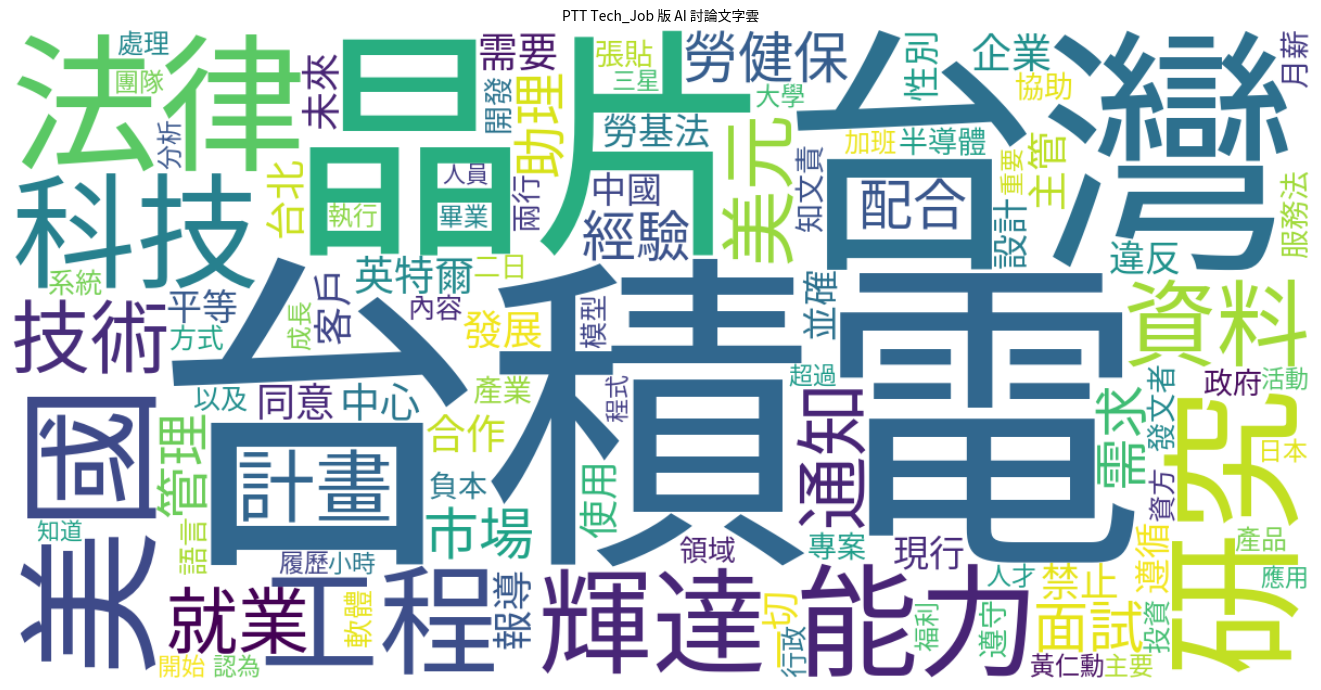

In [12]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字型
!apt-get install -y fonts-noto-cjk -q
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
prop = fm.FontProperties(fname=font_path)

# 詞頻統計
all_words = [w for tokens in df['tokens'] for w in tokens]
word_freq = Counter(all_words)

print('最高頻前20詞：')
print(word_freq.most_common(20))

# 畫文字雲
wc = WordCloud(
    font_path=font_path,
    width=1200, height=600,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('PTT Tech_Job 版 AI 討論文字雲', fontsize=16, fontproperties=prop)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## LDA 主題模型
使用 LDA 自動探索語料中的潛在主題。

In [13]:
import warnings
warnings.filterwarnings('ignore')

!pip install gensim pyLDAvis -q

from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

texts = df['tokens'].tolist()
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f'字典大小：{len(dictionary)}')

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=15,
    alpha='auto'
)

print('\n=== LDA 主題結果 ===')
for idx, topic in lda_model.print_topics(num_words=8):
    print(f'\n主題 {idx+1}：{topic}')

# pyLDAvis 互動圖
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis, 'lda_vis.html')
vis

字典大小：19184



=== LDA 主題結果 ===

主題 1：0.013*"法律" + 0.009*"勞健保" + 0.008*"配合" + 0.007*"勞基法" + 0.007*"通知" + 0.006*"同意" + 0.006*"違反" + 0.006*"禁止"

主題 2：0.012*"晶片" + 0.009*"美國" + 0.007*"輝達" + 0.007*"美元" + 0.006*"技術" + 0.006*"市場" + 0.006*"英特爾" + 0.006*"科技"

主題 3：0.011*"工程" + 0.009*"面試" + 0.006*"主管" + 0.006*"知道" + 0.005*"程式" + 0.005*"需要" + 0.004*"經驗" + 0.004*"討論"

主題 4：0.060*"台積電" + 0.023*"台灣" + 0.008*"半導體" + 0.008*"日本" + 0.007*"人才" + 0.007*"記者" + 0.005*"董事" + 0.005*"產業"

主題 5：0.015*"研究" + 0.013*"計畫" + 0.011*"助理" + 0.009*"法律" + 0.008*"資料" + 0.008*"就業" + 0.008*"通知" + 0.007*"能力"


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.214816  0.009925       1        1  36.518957
2      0.043691  0.249618       2        1  19.906823
0     -0.211326 -0.026835       3        1  16.407590
4     -0.252136 -0.063413       4        1  14.506285
3      0.204954 -0.169295       5        1  12.660346, topic_info=      Term          Freq         Total Category  logprob  loglift
1943   台積電  10373.000000  10373.000000  Default  30.0000  30.0000
1337    台灣   6166.000000   6166.000000  Default  29.0000  29.0000
7203    晶片   5588.000000   5588.000000  Default  28.0000  28.0000
84      法律   4305.000000   4305.000000  Default  27.0000  27.0000
250     研究   4255.000000   4255.000000  Default  26.0000  26.0000
...    ...           ...           ...      ...      ...      ...
11732   輝達    650.287911   3959.275955   Topic5  -5.4724   0.2603
135     需求    585.342264   2712.230235   Topic5  -5.5776   0.5334
726     企業    538.355122   2533.976997   Topic5  -5.6613   0.5177
2516    美國    532.655171   4609.460214   Topic5  -5.6720  -0.0913
2004    未來    505.083813   2380.118026   Topic5  -5.7251   0.5165

[430 rows x 6 columns], token_table=       Topic      Freq Term
term                       
3127       1  0.009273   一下
3127       2  0.989856   一下
0          1  0.050485   一切
0          2  0.025242   一切
0          3  0.578283   一切
...      ...       ...  ...
15757      5  0.998278  魏哲家
10087      1  0.995215  黃仁勳
10087      5  0.004706  黃仁勳
137        3  0.720372   黨派
137        4  0.279388   黨派

[841 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1, 5, 4])

## Guided LDA
透過預設種子詞，引導模型找出四個特定主題：
薪資報酬與分紅福利、職場文化與勞動環境、面試求職與錄取請益、產業前景與高層巨頭動態、裁員風暴與組織人事異動

In [14]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models import LdaModel

seed_topics = {
    0: ['薪資', '分紅', '年終', '開獎', '結構', '底薪', '年薪', '福利', '調薪', '破百'],
    1: ['加班', '輪班', '值班', '文化', '風氣', '主管', '壓力', '血汗', '高壓', '生活平衡'],
    2: ['面試', '請益', '錄取', '轉職', '人資', '口試', '學歷', '職缺', '考試', '年資'],
    3: ['建廠', '產能', '晶圓', '營收', '財報', '股價', '黃仁勳', '概念股', '轉型', '擴廠', '晶片', '科技', '領域'],
    4: ['裁員', '凍結', '縮編', '優退', '人事', '外商', '景氣', '優離', '部門', '解雇'],
}
topic_names = ['薪資報酬與分紅福利', '職場文化與勞動環境', '面試求職與錄取請益', '產業前景與高層巨頭動', '裁員風暴與組織人事異動']

# 種子詞強化
guided_texts = df['tokens'].tolist()
for words in seed_topics.values():
    for word in words:
        guided_texts.append([word] * 5)

guided_dict = corpora.Dictionary(guided_texts)
guided_dict.filter_extremes(no_below=3, no_above=0.6)
guided_corpus = [guided_dict.doc2bow(t) for t in guided_texts]

# 初始化 eta 矩陣 (形狀為 num_topics * num_terms)
num_terms = len(guided_dict)
eta = np.ones((5, num_terms)) * 0.01  # 給予一個很小的基礎權重

guided_lda = LdaModel(
    corpus=guided_corpus,
    id2word=guided_dict,
    num_topics=5,
    random_state=42,
    passes=20,
    alpha='auto',
    eta=eta
)

print('=== Guided LDA 主題結果 ===')
for i in range(5):
    words = '、'.join([w for w, _ in guided_lda.show_topic(i, topn=8)])
    print(f'\n主題 {i+1}【{topic_names[i]}】：{words}')

def get_dominant_topic(bow):
    topics = guided_lda.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else 0

df['guided_topic'] = [get_dominant_topic(guided_dict.doc2bow(t)) for t in df['tokens']]
df['guided_topic_name'] = df['guided_topic'].map(dict(enumerate(topic_names)))

print('\n=== 各主題文章數量 ===')
print(df['guided_topic_name'].value_counts())

=== Guided LDA 主題結果 ===

主題 1【薪資報酬與分紅福利】：工程、面試、主管、知道、需要、經驗、討論、年薪

主題 2【職場文化與勞動環境】：研究、問卷、大學、報名、博士、畢業、中心、訓練

主題 3【面試求職與錄取請益】：法律、勞健保、通知、配合、就業、助理、計畫、勞基法

主題 4【產業前景與高層巨頭動】：晶片、技術、市場、中國、模型、科技、三星、使用

主題 5【裁員風暴與組織人事異動】：台積電、台灣、美國、半導體、報導、科技、政府、投資

=== 各主題文章數量 ===
guided_topic_name
面試求職與錄取請益      2152
薪資報酬與分紅福利      2031
裁員風暴與組織人事異動    1647
產業前景與高層巨頭動     1360
職場文化與勞動環境       265
Name: count, dtype: int64


### 準備 Gephi 視覺化的資料

為了使用 Gephi 這樣的網路視覺化工具，我們需要將 LDA 模型的主題-詞彙分佈轉換成節點 (Nodes) 和邊 (Edges) 的格式。以下步驟將幫助您生成這兩個 CSV 檔案：

1.  **生成節點檔案 (`nodes.csv`)**：包含所有主題和每個主題下的關鍵詞。每個詞彙和每個主題都將是一個節點。
2.  **生成邊檔案 (`edges.csv`)**：定義主題與其關鍵詞之間的連結，並以詞彙在主題中的權重作為邊的強度。

您可以在 Gephi 中導入這兩個檔案來建立視覺化圖，探索主題內部的詞彙結構。

In [15]:
import pandas as pd

# 提取主題-詞彙分佈
topic_word_dist = []
for i in range(guided_lda.num_topics):
    for word, prob in guided_lda.show_topic(i, topn=30): # 每個主題取前30個詞
        topic_word_dist.append({'topic_id': i, 'topic_name': topic_names[i], 'word': word, 'probability': prob})

topic_word_df = pd.DataFrame(topic_word_dist)
display(topic_word_df.head())


,topic_id,topic_name,word,probability
0,0,薪資報酬與分紅福利,工程,0.014236
1,0,薪資報酬與分紅福利,面試,0.009455
2,0,薪資報酬與分紅福利,主管,0.007157
3,0,薪資報酬與分紅福利,知道,0.006409
4,0,薪資報酬與分紅福利,需要,0.005441


In [16]:
# 創建節點檔案 (nodes.csv)

nodes = []

# 添加主題節點
for i, name in enumerate(topic_names):
    nodes.append({'Id': f'T{i}', 'Label': name, 'Type': 'Topic'})

# 添加詞彙節點
# 為了避免重複，先收集所有獨特的詞彙
all_words_in_topics = topic_word_df['word'].unique()
for word in all_words_in_topics:
    nodes.append({'Id': f'W_{word}', 'Label': word, 'Type': 'Word'})

nodes_df = pd.DataFrame(nodes)
nodes_df.to_csv('nodes.csv', index=False)

print(f"節點檔案 'nodes.csv' 已生成，包含 {len(nodes_df)} 個節點。")
display(nodes_df.head())


節點檔案 'nodes.csv' 已生成，包含 138 個節點。


,Id,Label,Type
0,T0,薪資報酬與分紅福利,Topic
1,T1,職場文化與勞動環境,Topic
2,T2,面試求職與錄取請益,Topic
3,T3,產業前景與高層巨頭動,Topic
4,T4,裁員風暴與組織人事異動,Topic


In [17]:
# 創建邊檔案 (edges.csv)

edges = []
for index, row in topic_word_df.iterrows():
    edges.append({
        'Source': f'T{row['topic_id']}',
        'Target': f'W_{row['word']}',
        'Weight': row['probability'],
        'Type': 'Topic-Word'
    })

edges_df = pd.DataFrame(edges)
edges_df.to_csv('edges.csv', index=False)

print(f"邊檔案 'edges.csv' 已生成，包含 {len(edges_df)} 條邊。")
display(edges_df.head())


邊檔案 'edges.csv' 已生成，包含 150 條邊。


,Source,Target,Weight,Type
0,T0,W_工程,0.014236,Topic-Word
1,T0,W_面試,0.009455,Topic-Word
2,T0,W_主管,0.007157,Topic-Word
3,T0,W_知道,0.006409,Topic-Word
4,T0,W_需要,0.005441,Topic-Word


### 如何在 Gephi 中導入並視覺化

1.  **啟動 Gephi**：打開 Gephi 軟體並選擇「New Project」。
2.  **導入節點檔案**：
    *   點擊「Data Laboratory」標籤。
    *   選擇「Import Spreadsheet」圖示。
    *   瀏覽並選擇 `nodes.csv` 檔案。
    *   在導入設定中，確認「As Table: Nodes」被選中。
    *   確認欄位對應正確（例如 `Id` 對應 `ID`，`Label` 對應 `Label`，`Type` 對應 `Type`）。
    *   點擊「Finish」。
3.  **導入邊檔案**：
    *   再次點擊「Import Spreadsheet」圖示。
    *   瀏覽並選擇 `edges.csv` 檔案。
    *   在導入設定中，確認「As Table: Edges」被選中。
    *   確認欄位對應正確（例如 `Source` 對應 `Source`，`Target` 對應 `Target`，`Weight` 對應 `Weight`，`Type` 對應 `Type`）。
    *   點擊「Finish」。
4.  **切換到概覽 (Overview)**：導入完成後，切換回「Overview」標籤。
5.  **應用佈局 (Layout)**：在左側的「Layout」面板中，選擇一個佈局演算法，例如 `ForceAtlas 2` 或 `Fruchterman Reingold`，然後點擊「Run」來組織您的網路圖。
6.  **調整外觀 (Appearance)**：在「Appearance」面板中，您可以根據節點類型（例如 `Type` 屬性）來調整節點顏色、大小，或根據邊的權重調整邊的粗細，以美化您的視覺化。

透過這些步驟，您就可以在 Gephi 中探索主題和詞彙之間的關係了！

### 在 Python 中視覺化主題-詞彙網絡

如果您更傾向於在 Python 環境中進行視覺化，可以使用 `networkx` 庫來建立和操作圖形，並結合 `matplotlib` 進行繪製。這能讓您直接在 Colab 環境中看到主題與其相關詞彙的連接關係。

Reading package lists...
Building dependency tree...
Reading state information...
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Matplotlib cache cleared.
Matplotlib font manager reloaded.
Using font family name: 'Noto Sans CJK JP' from '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
Matplotlib rcParams updated for font.family with 'Noto Sans CJK JP'.


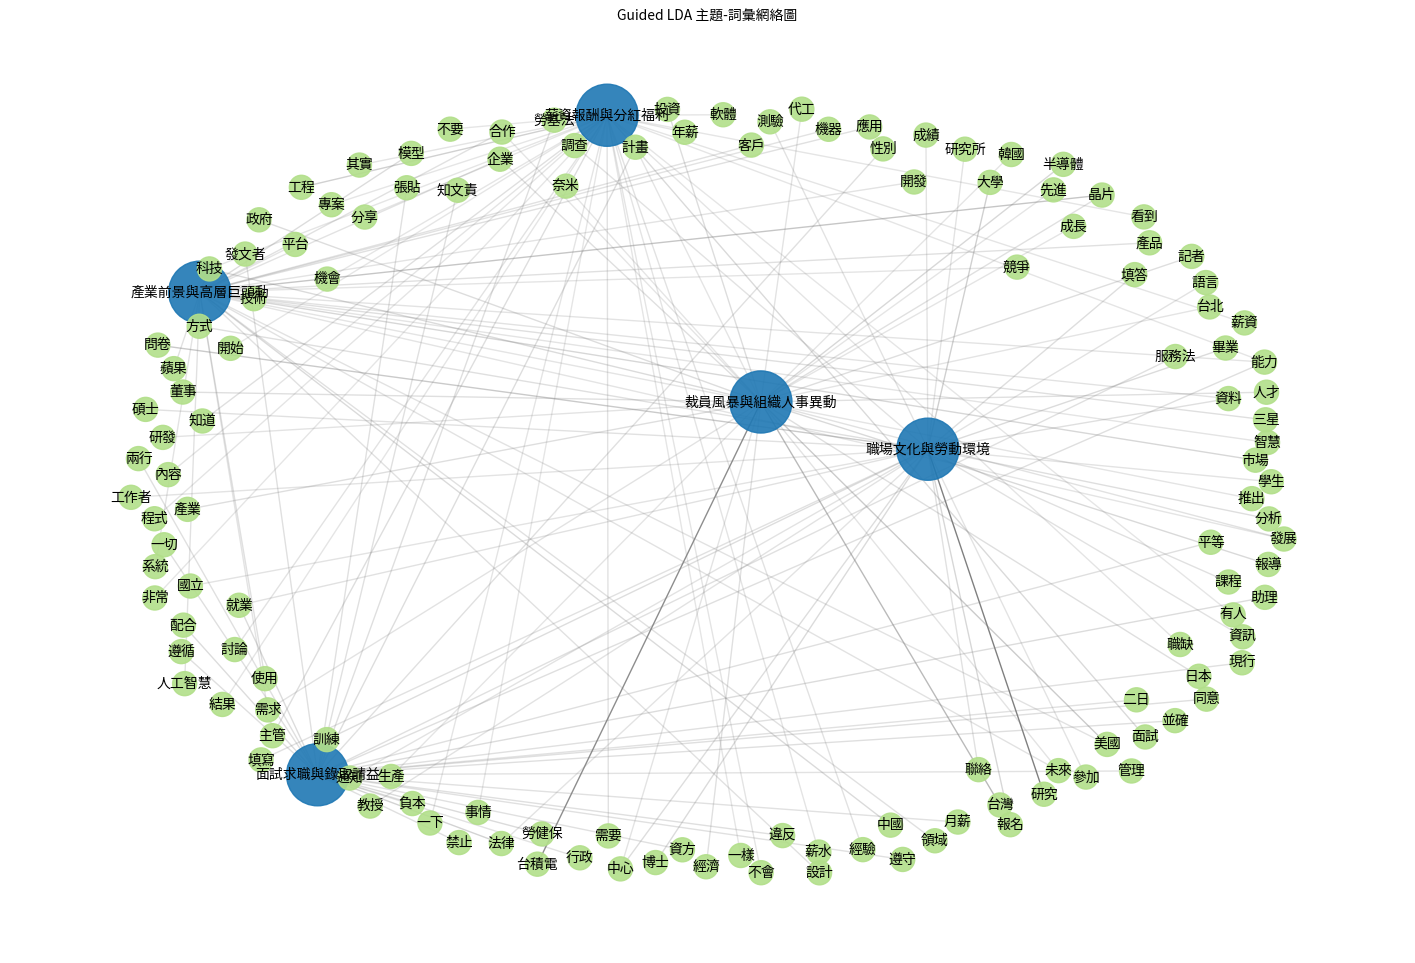

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm
import os

# 確保字體可用 (如果您在 Colab 中運行，可能需要再次安裝)
!apt-get install -y fonts-noto-cjk -q

# 清除 matplotlib 字體快取並重新載入
if os.path.exists('/root/.cache/matplotlib'):
    !rm -rf /root/.cache/matplotlib
    print("Matplotlib cache cleared.")

# Force a rebuild of the font cache by re-importing fm
# This ensures the font manager re-scans system fonts after installation/cache clearing.
del fm
import matplotlib.font_manager as fm
print("Matplotlib font manager reloaded.")

font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'

prop = None
font_family_name = 'sans-serif' # Default fallback

if not os.path.exists(font_path):
    print(f"Warning: Font file not found at {font_path}. Using default font.")
    # Fallback to a generic font property if the specific font file isn't found
    prop = fm.FontProperties()
else:
    # Explicitly add the font to the font manager
    fm.fontManager.addfont(font_path)
    # Create FontProperties object
    prop = fm.FontProperties(fname=font_path)
    font_family_name = prop.get_name() # Get the actual family name registered by matplotlib
    print(f"Using font family name: '{font_family_name}' from '{font_path}'")

    # Set the default font for matplotlib using rcParams
    # This is a common and robust way to handle CJK fonts in Colab
    plt.rcParams['font.sans-serif'] = [font_family_name] # Set 'sans-serif' to ONLY be this font
    plt.rcParams['font.family'] = ['sans-serif']       # Make 'sans-serif' the primary font family
    plt.rcParams['axes.unicode_minus'] = False         # Ensure minus signs display correctly
    print(f"Matplotlib rcParams updated for font.family with '{font_family_name}'.")

# 載入之前生成的節點和邊檔案
nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')

# 創建一個空的圖
G = nx.Graph()

# 添加節點
for index, row in nodes_df.iterrows():
    G.add_node(row['Id'], label=row['Label'], type=row['Type'])

# 添加邊
for index, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

# 設定節點顏色和大小
node_colors = []
node_sizes = []
labels = {}

for node in G.nodes(data=True):
    node_id = node[0]
    node_attr = node[1]
    labels[node_id] = node_attr['label']

    if node_attr['type'] == 'Topic':
        node_colors.append('#1f78b4')  # 藍色用於主題
        node_sizes.append(2000)      # 主題節點較大
    else:
        node_colors.append('#b2df8a')  # 淺綠色用於詞彙
        # 為了使詞彙節點大小有所區別，可以根據其在所有主題中的總概率進行調整
        # 這需要重新計算或從 topic_word_df 中獲取詞彙的總體概率
        # 為了簡單起見，這裡只給一個基礎大小
        node_sizes.append(300)

# 設定邊的透明度（權重越高，顏色越深）
edge_weights = [d['weight'] for (u, v, d) in G.edges(data=True)]
# 為了視覺化效果，將權重轉換為適合透明度的範圍
min_w = min(edge_weights)
max_w = max(edge_weights)
normalized_weights = [(w - min_w) / (max_w - min_w) for w in edge_weights]
edge_alphas = [w * 0.8 + 0.2 for w in normalized_weights] # 確保有最低透明度

# 使用 spring_layout 佈局
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # k 值越大，節點間距離越遠

# 繪製節點
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# 繪製邊
nx.draw_networkx_edges(G, pos, width=1, alpha=edge_alphas, edge_color='gray')

# 繪製標籤
# Explicitly set font_family for networkx labels to 'sans-serif' to use rcParams configured font
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family='sans-serif')

# Explicitly set fontproperties for plt.title
plt.title('Guided LDA 主題-詞彙網絡圖', fontsize=18, fontproperties=prop)
plt.axis('off')
plt.show()

In [19]:
import plotly.graph_objects as go

# Prepare data for Plotly
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None) # Separator for new line
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

node_x = []
node_y = []
node_text = []
node_color = []
node_size_plotly = []

for node_id, node_attr in G.nodes(data=True):
    x, y = pos[node_id]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node_attr['label'])

    if node_attr['type'] == 'Topic':
        node_color.append('#1f78b4') # Blue for topics
        node_size_plotly.append(20) # Larger for topics
    else:
        node_color.append('#b2df8a') # Light green for words
        node_size_plotly.append(10) # Smaller for words

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    text=node_text,
    textposition='top center',
    marker=dict(
        showscale=False,
        color=node_color,
        size=node_size_plotly,
        line_width=1))

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                 title='<br>Guided LDA 主題-詞彙網絡圖 (Plotly Interactive)',
                 titlefont_size=16,
                 showlegend=False,
                 hovermode='closest',
                 margin=dict(b=20,l=5,r=5,t=40),
                 annotations=[ dict(
                     text="Hover over nodes for labels",
                     showarrow=False,
                     xref="paper", yref="paper",
                     x=0.005, y=-0.002 ) ],
                 xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                 yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                 )

fig.show()

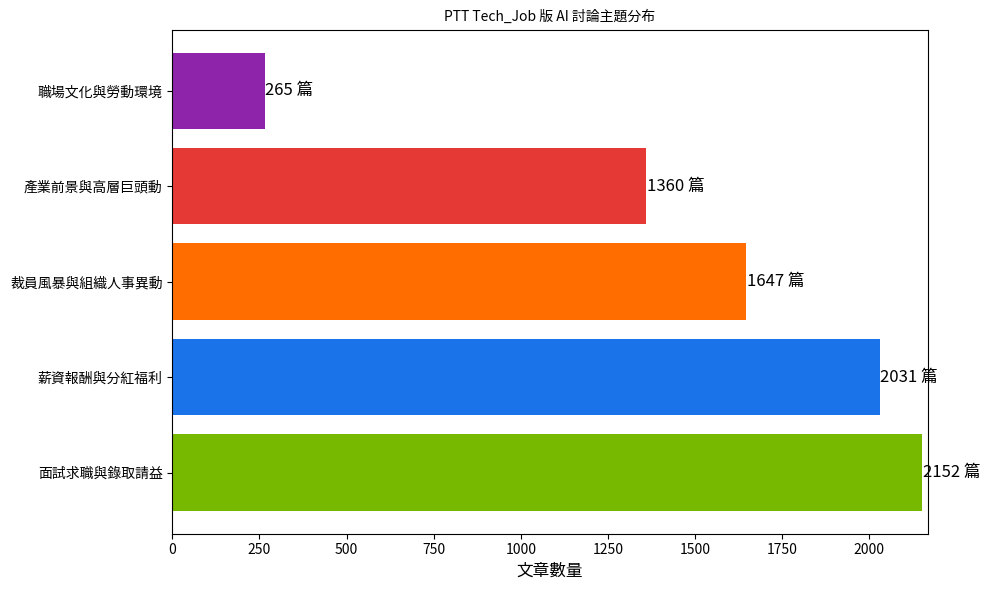

In [20]:
topic_counts = df['guided_topic_name'].value_counts()
colors = ['#76b900', '#1a73e8', '#ff6d00', '#e53935', '#8e24aa']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(topic_counts.index, topic_counts.values, color=colors)

for bar, val in zip(bars, topic_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val} 篇', va='center', fontsize=12, fontproperties=prop)

ax.set_xlabel('文章數量', fontsize=12, fontproperties=prop)
ax.set_title('PTT Tech_Job 版 AI 討論主題分布', fontsize=14, fontproperties=prop)
ax.set_yticklabels(topic_counts.index, fontproperties=prop)
ax.set_xlim(0, max(topic_counts.values) + 15)
plt.tight_layout()
plt.savefig('guided_lda_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 情緒分析
使用 SnowNLP 對每篇文章進行情緒評分（0～1），
分數越高代表越正面，越低代表越負面。
分析各主題的平均情緒傾向。

In [21]:
import warnings
warnings.filterwarnings('ignore')

!pip install snownlp -q

from snownlp import SnowNLP

def get_sentiment(text):
    try:
        return SnowNLP(text).sentiments
    except:
        return 0.5

df['sentiment'] = df['text_clean'].apply(get_sentiment)

# 情緒分類
def label_sentiment(score):
    if score >= 0.6:
        return '正面'
    elif score <= 0.4:
        return '負面'
    else:
        return '中立'

df['sentiment_label'] = df['sentiment'].apply(label_sentiment)

print('=== 整體情緒分布 ===')
print(df['sentiment_label'].value_counts())
print(f'\n平均情緒分數：{df["sentiment"].mean():.3f}')

=== 整體情緒分布 ===
sentiment_label
負面    6162
正面    1208
中立      85
Name: count, dtype: int64

平均情緒分數：0.170


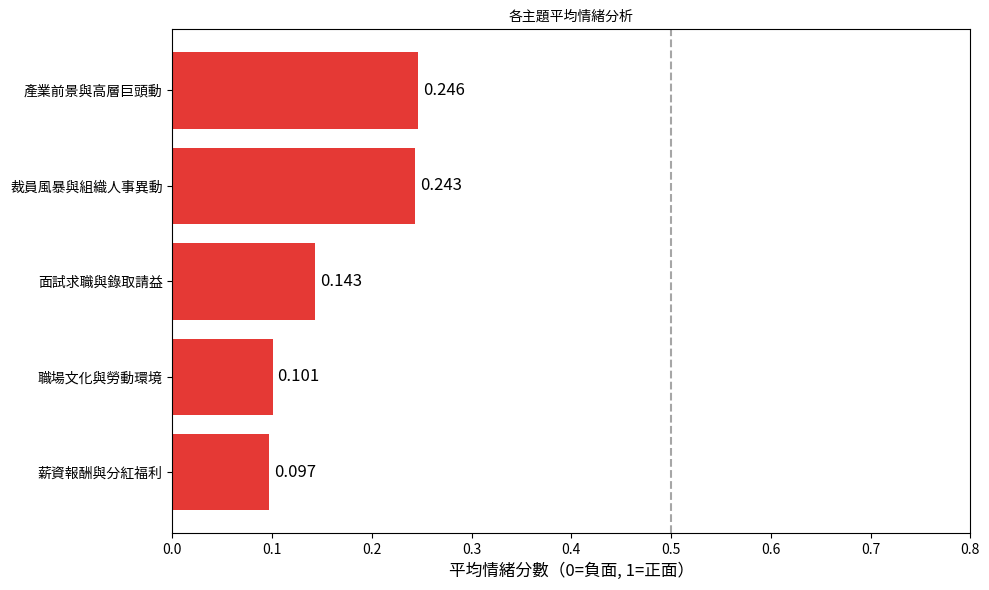

In [22]:
import matplotlib.pyplot as plt

topic_sentiment = df.groupby('guided_topic_name')['sentiment'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_s = ['#e53935' if v < 0.5 else '#76b900' for v in topic_sentiment.values]
bars = ax.barh(topic_sentiment.index, topic_sentiment.values, color=colors_s)

for bar, val in zip(bars, topic_sentiment.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=12, fontproperties=prop)

ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('平均情緒分數（0=負面, 1=正面）', fontsize=12, fontproperties=prop)
ax.set_title('各主題平均情緒分析', fontsize=14, fontproperties=prop)
ax.set_yticklabels(topic_sentiment.index, fontproperties=prop)
ax.set_xlim(0, 0.8)
plt.tight_layout()
plt.savefig('sentiment_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 情緒分析
使用 SnowNLP 對每篇文章進行情緒評分（0～1），
分數越高代表越正面，越低代表越負面。
分析各主題的平均情緒傾向。

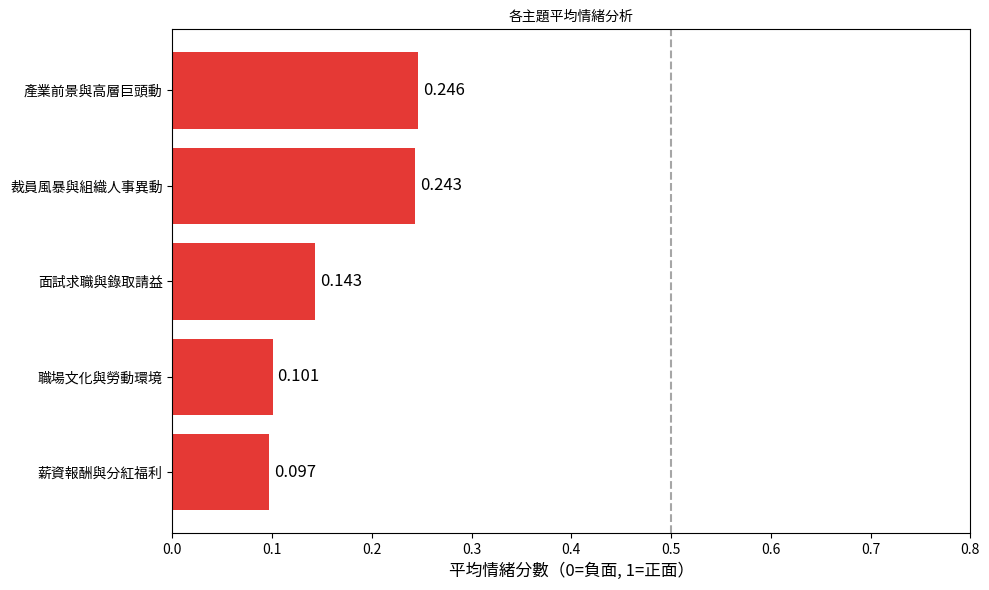

In [23]:
import matplotlib.pyplot as plt

topic_sentiment = df.groupby('guided_topic_name')['sentiment'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_s = ['#e53935' if v < 0.5 else '#76b900' for v in topic_sentiment.values]
bars = ax.barh(topic_sentiment.index, topic_sentiment.values, color=colors_s)

for bar, val in zip(bars, topic_sentiment.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=12, fontproperties=prop)

ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('平均情緒分數（0=負面, 1=正面）', fontsize=12, fontproperties=prop)
ax.set_title('各主題平均情緒分析', fontsize=14, fontproperties=prop)
ax.set_yticklabels(topic_sentiment.index, fontproperties=prop)
ax.set_xlim(0, 0.8)
plt.tight_layout()
plt.savefig('sentiment_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 洞察與結論

根據上述分析，本研究歸納出以下四大核心發現：

1. **台積電效應與法律意識**：
   - 在 AI 討論中，「台積電」具備壓倒性的討論熱度。
   - 與一般預期不同，社群對「法律」與「勞基法」的關注度極高，顯示 AI 相關職位（如助理、研究計畫）的勞動條件透明度是版友關注的重點。

2. **產業鏈高度連結全球動態**：
   - 關鍵字如「輝達」、「美國」、「晶片」顯示討論與全球半導體供應鏈高度掛鉤，反映出台灣 AI 職涯發展受地緣政治與巨頭公司動態影響深遠。

3. **面試資訊需求為最大宗**：
   - 從 Guided LDA 的數量分布來看，「面試求職與錄取請益」是版上最主要的互動需求，顯示 AI 領域的選才門檻與面試流程具有高度不確定性，需依賴社群經驗分享。

4. **情緒傾向分析**：
   - 透過情緒分析可觀察到，雖然 AI 是熱門科技議題，但涉及「裁員」、「加班」或「法令爭議」時，情緒分數顯著降低。這反映出科技從業者對 AI 熱潮背後的勞動強度與產業波動持謹慎、務實的態度。

In [24]:
import warnings
warnings.filterwarnings('ignore')

!pip install snownlp -q

from snownlp import SnowNLP

def get_sentiment(text):
    try:
        return SnowNLP(text).sentiments
    except:
        return 0.5

df['sentiment'] = df['text_clean'].apply(get_sentiment)

# 情緒分類
def label_sentiment(score):
    if score >= 0.6:
        return '正面'
    elif score <= 0.4:
        return '負面'
    else:
        return '中立'

df['sentiment_label'] = df['sentiment'].apply(label_sentiment)

print('=== 整體情緒分布 ===')
print(df['sentiment_label'].value_counts())
print(f'\n平均情緒分數：{df["sentiment"].mean():.3f}')

=== 整體情緒分布 ===
sentiment_label
負面    6162
正面    1208
中立      85
Name: count, dtype: int64

平均情緒分數：0.170
